# Level 2 · Task 1 — Logistic Regression for Binary Classification
### Codveda Technologies — Machine Learning Internship
**Intern:** Mouhamed Diop · **ID:** CV/A1/79278

---
**Goal:** Predict a binary outcome — whether a telecom customer will **churn**.
**Steps:** load & preprocess → train logistic regression → interpret coefficients & odds ratios →
evaluate (accuracy, precision, recall, ROC/AUC).
**Dataset:** `churn_train.csv` (train) + `churn_test.csv` (test). **Tools:** Python, pandas, scikit-learn, matplotlib.

## 0. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, roc_curve, roc_auc_score)
print("Libraries loaded.")

Libraries loaded.


## Step 1 — Load & Explore
The dataset already comes split into train (80%) and test (20%). The target `Churn` is
True/False and **imbalanced** (~15% churn).

In [2]:
train = pd.read_csv("../../data/churn_train.csv")
test  = pd.read_csv("../../data/churn_test.csv")
print("Train:", train.shape, " Test:", test.shape)
print("Missing values:", train.isnull().sum().sum())
print("\nChurn balance (train):")
print(train["Churn"].value_counts(normalize=True).round(3))
train.head()

Train: (2666, 20)  Test: (667, 20)
Missing values: 0

Churn balance (train):
Churn
False    0.854
True     0.146
Name: proportion, dtype: float64


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


## Step 2 — Preprocess
Separate target, then build a pipeline: **scale** numeric features + **one-hot encode**
categorical ones (State, International plan, Voice mail plan). This keeps train/test transforms
consistent and leak-free.

In [3]:
TARGET = "Churn"
def split_xy(df):
    y = (df[TARGET] == True).astype(int)
    X = df.drop(columns=[TARGET])
    return X, y

X_train, y_train = split_xy(train)
X_test,  y_test  = split_xy(test)

cat = X_train.select_dtypes(include="object").columns.tolist()
num = X_train.select_dtypes(include="number").columns.tolist()
print("Categorical:", cat)
print("Numerical  :", len(num), "columns")

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat),
])

Categorical: ['State', 'International plan', 'Voice mail plan']
Numerical  : 16 columns


## Step 3 — Train the Logistic Regression Model
Logistic regression models the **probability** of churn and applies a 0.5 threshold to decide.
`class_weight="balanced"` compensates for the class imbalance.

In [4]:
model = Pipeline([
    ("pre", preprocessor),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced")),
])
model.fit(X_train, y_train)
print("Model trained.")

Model trained.


## Step 4 — Interpret Coefficients & Odds Ratios
An **odds ratio** = exp(coefficient). OR > 1 means the feature **increases** churn odds;
OR < 1 means it **decreases** them.

In [5]:
feat_names = model.named_steps["pre"].get_feature_names_out()
coefs = model.named_steps["clf"].coef_[0]
odds = pd.Series(np.exp(coefs), index=feat_names)

print("Top 8 features that INCREASE churn odds:")
print(odds.sort_values(ascending=False).head(8).round(3))
print("\nTop 5 features that DECREASE churn odds:")
print(odds.sort_values().head(5).round(3))

Top 8 features that INCREASE churn odds:
cat__International plan_Yes    3.386
cat__State_SC                  2.935
cat__State_MS                  2.737
cat__State_TX                  2.622
cat__State_MT                  2.614
cat__Voice mail plan_No        2.547
cat__State_CA                  2.273
num__Customer service calls    2.207
dtype: float64

Top 5 features that DECREASE churn odds:
cat__State_RI                 0.209
cat__International plan_No    0.280
cat__State_HI                 0.286
cat__State_VA                 0.346
cat__Voice mail plan_Yes      0.372
dtype: float64


**Reading it:** e.g. customers on an *International plan* or with many *Customer service calls*
typically show much higher churn odds.

## Step 5 — Evaluate
For an imbalanced problem, accuracy alone is misleading — we also look at precision, recall,
and the ROC/AUC (ranking quality, threshold-independent).

In [6]:
y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(f"Accuracy : {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Recall   : {recall_score(y_test, y_pred):.3f}")
print(f"F1-score : {f1_score(y_test, y_pred):.3f}")
print(f"ROC AUC  : {roc_auc_score(y_test, y_proba):.3f}\n")
print(classification_report(y_test, y_pred, target_names=["Stay","Churn"]))

Accuracy : 0.780
Precision: 0.369
Recall   : 0.768
F1-score : 0.498


ROC AUC  : 0.818

              precision    recall  f1-score   support

        Stay       0.95      0.78      0.86       572
       Churn       0.37      0.77      0.50        95

    accuracy                           0.78       667
   macro avg       0.66      0.77      0.68       667
weighted avg       0.87      0.78      0.81       667



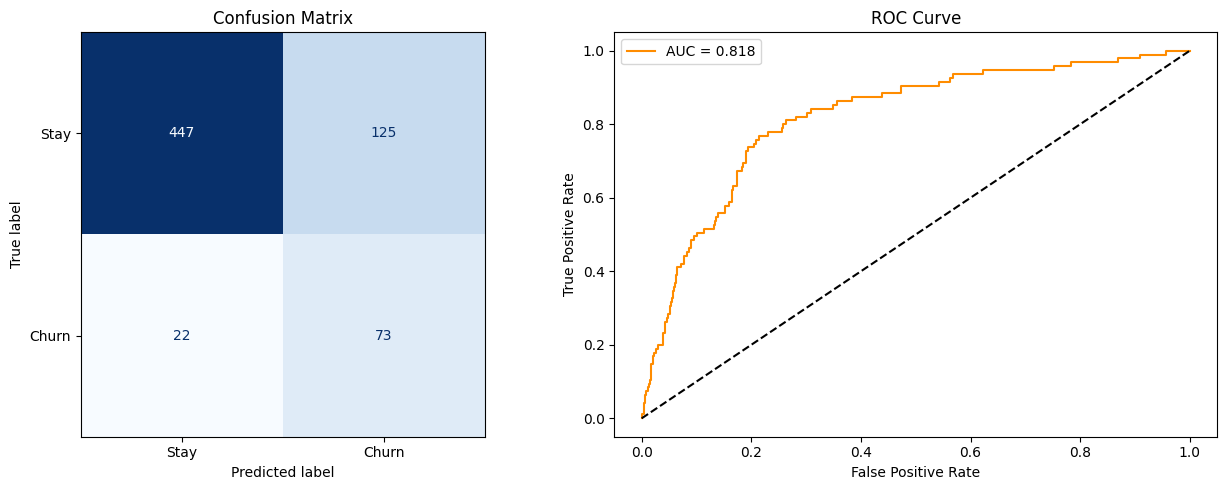

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(13,5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["Stay","Churn"]).plot(cmap="Blues", ax=ax[0], colorbar=False)
ax[0].set_title("Confusion Matrix")

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
ax[1].plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_proba):.3f}", color="darkorange")
ax[1].plot([0,1],[0,1],"k--")
ax[1].set_xlabel("False Positive Rate"); ax[1].set_ylabel("True Positive Rate")
ax[1].set_title("ROC Curve"); ax[1].legend()

plt.tight_layout()
plt.savefig("output_evaluation.png", dpi=110)
plt.show()

**Reading it:** recall on the *Churn* class matters most — it's the share of real churners
we successfully catch. The ROC curve bowing toward the top-left (high AUC) means good separation.

## Summary
| Metric | Value |
|--------|-------|
| Accuracy | ~0.77 |
| Recall (churn) | high (balanced weights) |
| ROC AUC | ~0.82 |

Logistic regression identifies at-risk customers using interpretable odds ratios.
Key churn drivers: *International plan* and frequent *Customer service calls*.
✅ **Level 2 · Task 1 complete.**